In [15]:
import pandas as pd
from sqlalchemy import create_engine, text

DATABASE_URL = "postgresql+psycopg:///orlando_demand_revenue"

engine = create_engine(DATABASE_URL)

query = text("""
    SELECT *
    FROM analytics.vw_forecast_input
    ORDER BY calendar_date
""")

with engine.connect() as connection:
    forecast_input = pd.read_sql_query(
        query,
        connection,
        parse_dates=["calendar_date"],
    )

forecast_input.shape

(1126, 27)

In [16]:
forecast_input.head()

,date_key,calendar_date,target_demand,has_actuals,day_of_week,day_of_year,week_of_year,month_number,quarter_number,year_number,...,planned_price_multiplier,active_campaign_count,maximum_planned_discount,paid_media_flag,email_campaign_flag,bundle_campaign_flag,discount_campaign_flag,available_capacity,demand_target,revenue_target
0,20230101,2023-01-01,2006.0,True,7,1,52,1,1,2023,...,1.1681,0,0.0,0,0,0,0,2500,2006,249298.65
1,20230102,2023-01-02,1333.0,True,1,2,1,1,1,2023,...,1.1473,0,0.0,0,0,0,0,2500,1290,157461.97
2,20230103,2023-01-03,854.0,True,2,3,1,1,1,2023,...,0.9448,0,0.0,0,0,0,0,2350,908,91271.40
3,20230104,2023-01-04,836.0,True,3,4,1,1,1,2023,...,0.9639,0,0.0,0,0,0,0,2350,911,93424.19
4,20230105,2023-01-05,877.0,True,4,5,1,1,1,2023,...,0.9278,0,0.0,0,0,0,0,2350,1046,103251.18


In [17]:
forecast_input.tail()

,date_key,calendar_date,target_demand,has_actuals,day_of_week,day_of_year,week_of_year,month_number,quarter_number,year_number,...,planned_price_multiplier,active_campaign_count,maximum_planned_discount,paid_media_flag,email_campaign_flag,bundle_campaign_flag,discount_campaign_flag,available_capacity,demand_target,revenue_target
1121,20260126,2026-01-26,NaN,False,1,26,5,1,1,2026,...,0.9351,0,0.0,0,0,0,0,2350,1036,103068.70
1122,20260127,2026-01-27,NaN,False,2,27,5,1,1,2026,...,0.9817,0,0.0,0,0,0,0,2350,934,97551.65
1123,20260128,2026-01-28,NaN,False,3,28,5,1,1,2026,...,0.9317,0,0.0,0,0,0,0,2350,1014,100513.18
1124,20260129,2026-01-29,NaN,False,4,29,5,1,1,2026,...,0.9591,0,0.0,0,0,0,0,2350,1081,110305.85
1125,20260130,2026-01-30,NaN,False,5,30,5,1,1,2026,...,0.9418,0,0.0,0,0,0,0,2350,1303,130560.58


In [18]:
forecast_input.columns.tolist()

['date_key',
 'calendar_date',
 'target_demand',
 'has_actuals',
 'day_of_week',
 'day_of_year',
 'week_of_year',
 'month_number',
 'quarter_number',
 'year_number',
 'is_weekend',
 'holiday_flag',
 'school_break_flag',
 'season',
 'observed_temperature_f',
 'observed_precipitation_in',
 'observed_severe_weather_flag',
 'planned_price_multiplier',
 'active_campaign_count',
 'maximum_planned_discount',
 'paid_media_flag',
 'email_campaign_flag',
 'bundle_campaign_flag',
 'discount_campaign_flag',
 'available_capacity',
 'demand_target',
 'revenue_target']

In [19]:
historical = forecast_input[
    forecast_input["target_demand"].notna()
].copy()

future = forecast_input[
    forecast_input["target_demand"].isna()
].copy()

print(
    "Historical:",
    len(historical),
    historical["calendar_date"].min(),
    "to",
    historical["calendar_date"].max(),
)

print(
    "Future:",
    len(future),
    future["calendar_date"].min(),
    "to",
    future["calendar_date"].max(),
)

Historical: 1096 2023-01-01 00:00:00 to 2025-12-31 00:00:00
Future: 30 2026-01-01 00:00:00 to 2026-01-30 00:00:00


In [20]:
assert forecast_input["calendar_date"].is_unique
assert forecast_input["calendar_date"].is_monotonic_increasing
assert forecast_input["calendar_date"].diff().dropna().eq(
    pd.Timedelta(days=1)
).all()

assert len(historical) == 1096
assert len(future) == 30
assert historical["calendar_date"].max() < future["calendar_date"].min()

assert future["observed_temperature_f"].isna().all()
assert future["observed_precipitation_in"].isna().all()

print("Forecast input validation passed.")

Forecast input validation passed.


(array([ 44., 201., 245., 195., 146., 120.,  72.,  33.,  22.,  18.]),
 array([ 669. ,  852.1, 1035.2, 1218.3, 1401.4, 1584.5, 1767.6, 1950.7,
        2133.8, 2316.9, 2500. ]),
 <BarContainer object of 10 artists>)

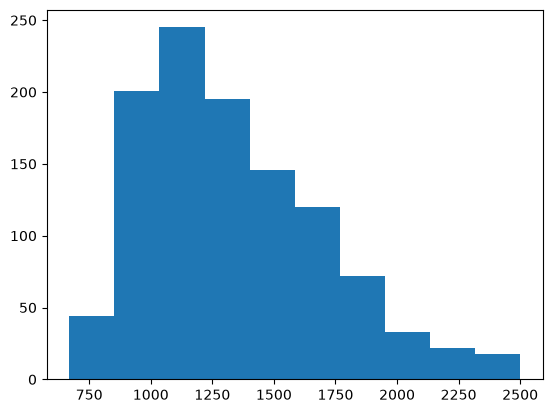

In [21]:
import matplotlib.pyplot as plt
plt.hist(historical['target_demand'])

In [22]:
year_summary = (
    historical
    .assign(year=historical["calendar_date"].dt.year)
    .groupby("year")
    .agg(
        days=("target_demand", "size"),
        total_demand=("target_demand", "sum"),
        average_daily_demand=("target_demand", "mean"),
        maximum_daily_demand=("target_demand", "max"),
    )
    .round(1)
)

year_summary

,days,total_demand,average_daily_demand,maximum_daily_demand
year,,,,
2023,365,470907.0,1290.2,2486.0
2024,366,490981.0,1341.5,2500.0
2025,365,504716.0,1382.8,2500.0


In [23]:
day_names = {
    1: "Monday",
    2: "Tuesday",
    3: "Wednesday",
    4: "Thursday",
    5: "Friday",
    6: "Saturday",
    7: "Sunday",
}

overall_average = historical["target_demand"].mean()

weekday_summary = (
    historical
    .groupby("day_of_week")
    .agg(
        days=("target_demand", "size"),
        average_demand=("target_demand", "mean"),
        median_demand=("target_demand", "median"),
        maximum_demand=("target_demand", "max"),
    )
    .assign(
        weekday=lambda table: table.index.map(day_names),
        demand_index=lambda table: (
            table["average_demand"] / overall_average
        ),
    )
    [
        [
            "weekday",
            "days",
            "average_demand",
            "median_demand",
            "maximum_demand",
            "demand_index",
        ]
    ]
    .round(2)
)

weekday_summary

,weekday,days,average_demand,median_demand,maximum_demand,demand_index
day_of_week,,,,,,
1,Monday,157,1119.17,1093.0,1540.0,0.84
2,Tuesday,157,1043.66,1018.0,1595.0,0.78
3,Wednesday,157,1087.29,1060.0,1662.0,0.81
4,Thursday,156,1193.17,1164.5,1730.0,0.89
5,Friday,156,1413.14,1399.5,2036.0,1.06
6,Saturday,156,1876.08,1826.0,2500.0,1.40
7,Sunday,157,1637.46,1608.0,2500.0,1.22


In [24]:
import calendar

monthly_summary = (
    historical
    .groupby("month_number")
    .agg(
        days=("target_demand", "size"),
        average_demand=("target_demand", "mean"),
        median_demand=("target_demand", "median"),
        maximum_demand=("target_demand", "max"),
    )
    .assign(
        month=lambda table: table.index.map(
            lambda month_number: calendar.month_abbr[month_number]
        ),
        demand_index=lambda table: (
            table["average_demand"] / overall_average
        ),
    )
    [
        [
            "month",
            "days",
            "average_demand",
            "median_demand",
            "maximum_demand",
            "demand_index",
        ]
    ]
    .round(2)
)

monthly_summary

,month,days,average_demand,median_demand,maximum_demand,demand_index
month_number,,,,,,
1,Jan,93,1217.69,1174.0,2197.0,0.91
2,Feb,85,1271.55,1160.0,2159.0,0.95
3,Mar,93,1411.44,1364.0,2160.0,1.05
4,Apr,90,1256.78,1149.0,2048.0,0.94
5,May,93,1319.81,1226.0,2486.0,0.99
6,Jun,90,1639.69,1522.0,2500.0,1.23
7,Jul,93,1570.63,1447.0,2500.0,1.17
8,Aug,93,1260.89,1189.0,2500.0,0.94
9,Sep,90,1136.86,1045.5,1814.0,0.85


In [25]:
def summarize_binary_feature(data, feature):
    return (
        data
        .groupby(feature)
        .agg(
            days=("target_demand", "size"),
            average_demand=("target_demand", "mean"),
            median_demand=("target_demand", "median"),
        )
        .assign(
            demand_index=lambda table: (
                table["average_demand"] / overall_average
            )
        )
        .round(2)
    )


display(summarize_binary_feature(historical, "is_weekend"))
display(summarize_binary_feature(historical, "holiday_flag"))
display(summarize_binary_feature(historical, "school_break_flag"))

,days,average_demand,median_demand,demand_index
is_weekend,,,,
False,783,1170.95,1127.0,0.88
True,313,1756.39,1718.0,1.31


,days,average_demand,median_demand,demand_index
holiday_flag,,,,
False,1061,1336.96,1271.0,1.00
True,35,1374.06,1338.0,1.03


,days,average_demand,median_demand,demand_index
school_break_flag,,,,
False,802,1252.56,1146.5,0.94
True,294,1571.59,1469.5,1.17


## Rolling-origin backtest design

Models are evaluated using twelve historical forecast origins. At each
origin, the model can only use information available on or before the
cutoff date and predicts the following 30 days.

This design reproduces the intended monthly forecasting process and
prevents future information leakage.

In [26]:
FORECAST_HORIZON = 30

backtest_cutoffs = pd.date_range(
    start="2024-12-31",
    end="2025-11-30",
    freq="ME",
)

backtest_plan = pd.DataFrame({
    "forecast_created_date": backtest_cutoffs,
})

backtest_plan["test_start"] = (
    backtest_plan["forecast_created_date"]
    + pd.Timedelta(days=1)
)

backtest_plan["test_end"] = (
    backtest_plan["forecast_created_date"]
    + pd.Timedelta(days=FORECAST_HORIZON)
)

backtest_plan["training_days"] = (
    backtest_plan["forecast_created_date"]
    .apply(
        lambda cutoff: historical["calendar_date"]
        .le(cutoff)
        .sum()
    )
)

assert len(backtest_plan) == 12
assert (
    backtest_plan["test_end"].max()
    <= historical["calendar_date"].max()
)

backtest_plan

,forecast_created_date,test_start,test_end,training_days
0,2024-12-31,2025-01-01,2025-01-30,731
1,2025-01-31,2025-02-01,2025-03-02,762
2,2025-02-28,2025-03-01,2025-03-30,790
3,2025-03-31,2025-04-01,2025-04-30,821
4,2025-04-30,2025-05-01,2025-05-30,851
5,2025-05-31,2025-06-01,2025-06-30,882
6,2025-06-30,2025-07-01,2025-07-30,912
7,2025-07-31,2025-08-01,2025-08-30,943
8,2025-08-31,2025-09-01,2025-09-30,974
9,2025-09-30,2025-10-01,2025-10-30,1004


### Forecast evaluation metrics

- **MAE:** Average absolute error in ticket units.
- **RMSE:** Similar to MAE but penalizes large errors more heavily.
- **MAPE:** Average absolute percentage error.
- **Forecast bias:** Average predicted demand minus actual demand.
  Positive bias means over-forecasting; negative bias means under-forecasting.

In [27]:
def calculate_forecast_metrics(predictions):
    actual = predictions["actual_demand"]
    predicted = predictions["predicted_demand"]
    error = predicted - actual

    nonzero_actual = actual.ne(0)

    return pd.Series({
        "observations": len(predictions),
        "mae": error.abs().mean(),
        "rmse": error.pow(2).mean() ** 0.5,
        "mape_pct": (
            error.loc[nonzero_actual].abs()
            / actual.loc[nonzero_actual]
        ).mean() * 100,
        "forecast_bias": error.mean(),
        "forecast_bias_pct": (
            error.sum() / actual.sum()
        ) * 100,
    })

### Baseline 1: Seven-day seasonal naive

The seasonal-naive model predicts demand from the most recently
available observation for the same day of the week. For horizons beyond
seven days, the last known seven-day demand pattern is repeated.

All reference dates must be on or before the forecast creation date.

In [28]:
seasonal_naive_predictions = []

target_lookup = historical.set_index(
    "calendar_date"
)["target_demand"]

for cutoff in backtest_plan["forecast_created_date"]:
    fold = historical.loc[
        historical["calendar_date"].gt(cutoff)
        & historical["calendar_date"].le(
            cutoff + pd.Timedelta(days=FORECAST_HORIZON)
        ),
        ["calendar_date", "target_demand"],
    ].copy()

    fold = fold.rename(
        columns={
            "calendar_date": "target_date",
            "target_demand": "actual_demand",
        }
    )

    fold["forecast_created_date"] = cutoff

    fold["horizon_days"] = (
        fold["target_date"] - cutoff
    ).dt.days

    weeks_back = (
        (fold["horizon_days"] - 1) // 7
    ) + 1

    fold["reference_date"] = (
        fold["target_date"]
        - pd.to_timedelta(weeks_back * 7, unit="D")
    )

    fold["predicted_demand"] = (
        fold["reference_date"].map(target_lookup)
    )

    fold["model_name"] = "seasonal_naive_7d"
    fold["model_version"] = "1.0"

    seasonal_naive_predictions.append(
        fold[
            [
                "forecast_created_date",
                "target_date",
                "horizon_days",
                "reference_date",
                "model_name",
                "model_version",
                "predicted_demand",
                "actual_demand",
            ]
        ]
    )

seasonal_naive_predictions = pd.concat(
    seasonal_naive_predictions,
    ignore_index=True,
)

### Accuracy by forecast horizon

Overall accuracy can hide deterioration at longer forecast horizons.
The 30-day horizon is divided into four operationally meaningful
groups to evaluate short- and long-range forecast performance.

In [29]:
horizon_analysis = seasonal_naive_predictions.copy()

horizon_analysis["horizon_bucket"] = pd.cut(
    horizon_analysis["horizon_days"],
    bins=[0, 7, 14, 21, 30],
    labels=[
        "Days 1-7",
        "Days 8-14",
        "Days 15-21",
        "Days 22-30",
    ],
)

horizon_metrics = (
    horizon_analysis
    .groupby(
        "horizon_bucket",
        observed=True,
    )
    .apply(
        calculate_forecast_metrics,
        include_groups=False,
    )
    .round(2)
)

assert horizon_metrics["observations"].sum() == 360

horizon_metrics

,observations,mae,rmse,mape_pct,forecast_bias,forecast_bias_pct
horizon_bucket,,,,,,
Days 1-7,84.0,190.45,245.44,13.99,15.05,1.09
Days 8-14,84.0,201.51,253.20,15.73,18.94,1.37
Days 15-21,84.0,214.67,274.43,17.15,21.43,1.56
Days 22-30,108.0,217.85,284.78,16.44,16.67,1.19


### Baseline 2: Twenty-eight-day moving average

This baseline calculates average daily demand from the 28 days available
immediately before each forecast creation date. The resulting average is
used as the prediction for every day in the following 30-day horizon.

The 28-day window covers four complete weeks, reducing the influence of
individual daily anomalies while reflecting the recent demand level.

Only observations available on or before each forecast creation date are
used, preventing future information leakage.

In [30]:
moving_average_predictions = []

MOVING_AVERAGE_WINDOW = 28

for cutoff in backtest_plan["forecast_created_date"]:
    training_window = (
        historical.loc[
            historical["calendar_date"].le(cutoff),
            ["calendar_date", "target_demand"],
        ]
        .sort_values("calendar_date")
        .tail(MOVING_AVERAGE_WINDOW)
    )

    assert len(training_window) == MOVING_AVERAGE_WINDOW
    assert training_window["calendar_date"].max() <= cutoff

    moving_average = training_window[
        "target_demand"
    ].mean()

    fold = historical.loc[
        historical["calendar_date"].gt(cutoff)
        & historical["calendar_date"].le(
            cutoff + pd.Timedelta(days=FORECAST_HORIZON)
        ),
        ["calendar_date", "target_demand"],
    ].copy()

    fold = fold.rename(
        columns={
            "calendar_date": "target_date",
            "target_demand": "actual_demand",
        }
    )

    fold["forecast_created_date"] = cutoff
    fold["horizon_days"] = (
        fold["target_date"] - cutoff
    ).dt.days

    fold["training_window_start"] = (
        training_window["calendar_date"].min()
    )
    fold["training_window_end"] = (
        training_window["calendar_date"].max()
    )

    fold["predicted_demand"] = moving_average
    fold["model_name"] = "moving_average_28d"
    fold["model_version"] = "1.0"

    moving_average_predictions.append(fold)

moving_average_predictions = pd.concat(
    moving_average_predictions,
    ignore_index=True,
)

In [31]:
baseline_comparison = pd.DataFrame({
    "seasonal_naive_7d": calculate_forecast_metrics(
        seasonal_naive_predictions
    ),
    "moving_average_28d": calculate_forecast_metrics(
        moving_average_predictions
    ),
}).T.round(2)

baseline_comparison

,observations,mae,rmse,mape_pct,forecast_bias,forecast_bias_pct
seasonal_naive_7d,360.0,206.90,266.30,15.87,17.93,1.29
moving_average_28d,360.0,313.42,384.55,23.25,-13.47,-0.97


## Leakage-safe weather features

Observed weather is available for model training but is not known for future
visit dates when a 30-day forecast is created.

For each backtest fold, monthly weather climatology is calculated using only
observations available on or before the forecast creation date. Historical
weather after the cutoff remains available for evaluation but is never used
as a model input.

In production, archived weather forecasts could replace climatology during
backtesting. Climatology is used here because equivalent historical forecast
snapshots are not available.

In [32]:
import numpy as np


# Purpose:
# Build leakage-safe training and validation data for one forecast origin.
#
# Used by:
# Every regression and machine-learning model evaluated in this notebook.
def build_backtest_fold(
    data,
    cutoff,
    forecast_horizon=30,
):
    cutoff = pd.Timestamp(cutoff)
    forecast_end = cutoff + pd.Timedelta(
        days=forecast_horizon
    )

    training = data.loc[
        data["target_demand"].notna()
        & data["calendar_date"].le(cutoff)
    ].copy()

    validation = data.loc[
        data["target_demand"].notna()
        & data["calendar_date"].gt(cutoff)
        & data["calendar_date"].le(forecast_end)
    ].copy()

    # Calculated only from weather available before the cutoff.
    climatology = (
        training
        .groupby(
            "month_number",
            as_index=False,
        )
        .agg(
            climatology_temperature_f=(
                "observed_temperature_f",
                "mean",
            ),
            climatology_precipitation_in=(
                "observed_precipitation_in",
                "mean",
            ),
            climatology_weather_risk=(
                "observed_severe_weather_flag",
                "mean",
            ),
            climatology_days=(
                "calendar_date",
                "size",
            ),
        )
    )

    # Historical training rows may use their observed weather.
    training["model_temperature_f"] = (
        training["observed_temperature_f"].astype(float)
    )
    training["model_precipitation_in"] = (
        training["observed_precipitation_in"].astype(float)
    )
    training["model_weather_risk"] = (
        training[
            "observed_severe_weather_flag"
        ].astype(float)
    )
    training["weather_feature_source"] = "observed"

    # Validation rows must emulate information available in advance.
    validation = validation.merge(
        climatology,
        on="month_number",
        how="left",
        validate="many_to_one",
    )

    validation["model_temperature_f"] = (
        validation["climatology_temperature_f"]
    )
    validation["model_precipitation_in"] = (
        validation["climatology_precipitation_in"]
    )
    validation["model_weather_risk"] = (
        validation["climatology_weather_risk"]
    )
    validation["weather_feature_source"] = (
        "training_monthly_climatology"
    )

    model_weather_columns = [
        "model_temperature_f",
        "model_precipitation_in",
        "model_weather_risk",
    ]

    return training, validation, climatology

In [33]:
example_cutoff = backtest_plan.loc[
    0,
    "forecast_created_date",
]

(
    example_training,
    example_validation,
    example_climatology,
) = build_backtest_fold(
    forecast_input,
    cutoff=example_cutoff,
    forecast_horizon=FORECAST_HORIZON,
)

print("Cutoff:", example_cutoff.date())
print("Training rows:", len(example_training))
print("Validation rows:", len(example_validation))
print(
    "Latest training date:",
    example_training["calendar_date"].max().date(),
)
print(
    "First validation date:",
    example_validation["calendar_date"].min().date(),
)

Cutoff: 2024-12-31
Training rows: 731
Validation rows: 30
Latest training date: 2024-12-31
First validation date: 2025-01-01


In [34]:
example_validation[
    [
        "calendar_date",
        "observed_temperature_f",
        "climatology_temperature_f",
        "model_temperature_f",
        "observed_precipitation_in",
        "climatology_precipitation_in",
        "model_precipitation_in",
        "weather_feature_source",
    ]
].head()

,calendar_date,observed_temperature_f,climatology_temperature_f,model_temperature_f,observed_precipitation_in,climatology_precipitation_in,model_precipitation_in,weather_feature_source
0,2025-01-01,63.5,63.274194,63.274194,0.0,0.041935,0.041935,training_monthly_climatology
1,2025-01-02,57.0,63.274194,63.274194,0.0,0.041935,0.041935,training_monthly_climatology
2,2025-01-03,56.0,63.274194,63.274194,0.0,0.041935,0.041935,training_monthly_climatology
3,2025-01-04,55.5,63.274194,63.274194,0.0,0.041935,0.041935,training_monthly_climatology
4,2025-01-05,57.5,63.274194,63.274194,0.0,0.041935,0.041935,training_monthly_climatology


### Rolling-origin evaluation of Ridge regression

The Ridge model is retrained independently at each of the same twelve
forecast origins used by both baseline models. Every training set contains
only data available on or before its forecast creation date, and every model
predicts the following 30 days.

All models are evaluated against the same forecast origins, target dates, and
actual demand values.

In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)


numeric_features = [
    "trend_days",
    "holiday_flag",
    "school_break_flag",
    "planned_price_multiplier",
    "active_campaign_count",
    "maximum_planned_discount",
    "paid_media_flag",
    "email_campaign_flag",
    "bundle_campaign_flag",
    "discount_campaign_flag",
    "model_temperature_f",
    "model_precipitation_in",
    "model_weather_risk",
]

categorical_features = [
    "day_of_week",
    "month_number",
]


# Purpose:
# Convert one fold into model-ready fields without changing its grain.
#
# Used by:
# Ridge regression and later machine-learning candidates.
def prepare_model_features(data):
    prepared = data.copy()

    prepared["trend_days"] = (
        prepared["calendar_date"]
        - forecast_input["calendar_date"].min()
    ).dt.days

    for column in numeric_features:
        prepared[column] = pd.to_numeric(
            prepared[column],
            errors="raise",
        ).astype(float)

    return prepared

In [36]:
ridge_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features,
        ),
        (
            "categorical",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
                sparse_output=False,
            ),
            categorical_features,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

ridge_pipeline = Pipeline(
    steps=[
        ("preprocessor", ridge_preprocessor),
        (
            "model",
            Ridge(alpha=10.0),
        ),
    ]
)

ridge_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{

In [37]:
from sklearn.base import clone


ridge_predictions = []

for cutoff in backtest_plan["forecast_created_date"]:
    training_fold, validation_fold, _ = (
        build_backtest_fold(
            forecast_input,
            cutoff=cutoff,
            forecast_horizon=FORECAST_HORIZON,
        )
    )

    training_features = prepare_model_features(
        training_fold
    )
    validation_features = prepare_model_features(
        validation_fold
    )

    fold_model = clone(ridge_pipeline)

    fold_model.fit(
        training_features,
        training_features["target_demand"],
    )

    predicted_demand = np.maximum(
        fold_model.predict(validation_features),
        0,
    )

    fold_predictions = pd.DataFrame({
        "forecast_created_date": cutoff,
        "target_date": validation_features[
            "calendar_date"
        ].to_numpy(),
        "horizon_days": (
            validation_features["calendar_date"]
            - cutoff
        ).dt.days.to_numpy(),
        "model_name": "ridge_regression",
        "model_version": "1.0",
        "predicted_demand": predicted_demand,
        "actual_demand": validation_features[
            "target_demand"
        ].to_numpy(),
    })

    ridge_predictions.append(fold_predictions)

ridge_predictions = pd.concat(
    ridge_predictions,
    ignore_index=True,
)

assert len(ridge_predictions) == 360
assert ridge_predictions[
    "forecast_created_date"
].nunique() == 12

assert ridge_predictions.groupby(
    "forecast_created_date"
).size().eq(30).all()

assert ridge_predictions[
    "predicted_demand"
].notna().all()

assert (
    ridge_predictions["predicted_demand"] >= 0
).all()

ridge_predictions.head()

,forecast_created_date,target_date,horizon_days,model_name,model_version,predicted_demand,actual_demand
0,2024-12-31,2025-01-01,1,ridge_regression,1.0,1307.640111,1390.0
1,2024-12-31,2025-01-02,2,ridge_regression,1.0,1371.366426,1496.0
2,2024-12-31,2025-01-03,3,ridge_regression,1.0,1548.524402,1585.0
3,2024-12-31,2025-01-04,4,ridge_regression,1.0,1664.945804,1382.0
4,2024-12-31,2025-01-05,5,ridge_regression,1.0,1432.964024,1372.0


## Candidate model 2: Histogram gradient boosting

Histogram gradient boosting captures nonlinear relationships and interactions
between calendar, weather, price, and campaign features.

The model uses the same inputs, forecast origins, horizons, and actual values
as Ridge regression and both baselines. Hyperparameters are specified in
advance rather than selected from the backtest results.

In [38]:
# Purpose:
# Evaluate one sklearn pipeline across all rolling forecast origins.
#
# Used by:
# Gradient boosting and subsequent sklearn model candidates.
def evaluate_sklearn_pipeline(
    model_template,
    model_name,
    model_version,
):
    prediction_folds = []

    for cutoff in backtest_plan[
        "forecast_created_date"
    ]:
        training_fold, validation_fold, _ = (
            build_backtest_fold(
                forecast_input,
                cutoff=cutoff,
                forecast_horizon=FORECAST_HORIZON,
            )
        )

        training_features = prepare_model_features(
            training_fold
        )
        validation_features = prepare_model_features(
            validation_fold
        )

        fold_model = clone(model_template)

        fold_model.fit(
            training_features,
            training_features["target_demand"],
        )

        predicted_demand = np.maximum(
            fold_model.predict(validation_features),
            0,
        )

        prediction_folds.append(
            pd.DataFrame({
                "forecast_created_date": cutoff,
                "target_date": validation_features[
                    "calendar_date"
                ].to_numpy(),
                "horizon_days": (
                    validation_features["calendar_date"]
                    - cutoff
                ).dt.days.to_numpy(),
                "model_name": model_name,
                "model_version": model_version,
                "predicted_demand": predicted_demand,
                "actual_demand": validation_features[
                    "target_demand"
                ].to_numpy(),
            })
        )

    predictions = pd.concat(
        prediction_folds,
        ignore_index=True,
    )

    assert len(predictions) == 360
    assert predictions[
        "forecast_created_date"
    ].nunique() == 12

    assert predictions.groupby(
        "forecast_created_date"
    ).size().eq(30).all()

    assert predictions[
        "predicted_demand"
    ].notna().all()

    return predictions

In [39]:
from sklearn.ensemble import (
    HistGradientBoostingRegressor,
)


gradient_boosting_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(ridge_preprocessor),
        ),
        (
            "model",
            HistGradientBoostingRegressor(
                loss="squared_error",
                learning_rate=0.05,
                max_iter=250,
                max_leaf_nodes=15,
                min_samples_leaf=20,
                l2_regularization=1.0,
                random_state=42,
            ),
        ),
    ]
)

gradient_boosting_predictions = (
    evaluate_sklearn_pipeline(
        model_template=gradient_boosting_pipeline,
        model_name="hist_gradient_boosting",
        model_version="1.0",
    )
)

## Candidate model 3: Holt-Winters exponential smoothing

Holt-Winters provides a classical time-series benchmark with an additive
weekly seasonal pattern and a damped trend.

The model uses only demand observations available before each forecast
origin. It cannot explain external demand drivers, but it tests whether
level, trend, and weekly seasonality are sufficient for accurate forecasting.

In [40]:
from statsmodels.tsa.holtwinters import (
    ExponentialSmoothing,
)


holt_winters_prediction_folds = []

for cutoff in backtest_plan[
    "forecast_created_date"
]:
    training_fold, validation_fold, _ = (
        build_backtest_fold(
            forecast_input,
            cutoff=cutoff,
            forecast_horizon=FORECAST_HORIZON,
        )
    )

    training_fold = training_fold.sort_values(
        "calendar_date"
    )
    validation_fold = validation_fold.sort_values(
        "calendar_date"
    )

    training_demand = (
        training_fold["target_demand"]
        .astype(float)
        .to_numpy()
    )

    fold_model = ExponentialSmoothing(
        training_demand,
        trend="add",
        damped_trend=True,
        seasonal="add",
        seasonal_periods=7,
        initialization_method="estimated",
    ).fit(
        optimized=True,
        use_brute=True,
        remove_bias=False,
    )

    predicted_demand = np.maximum(
        np.asarray(
            fold_model.forecast(
                FORECAST_HORIZON
            )
        ),
        0,
    )

    holt_winters_prediction_folds.append(
        pd.DataFrame({
            "forecast_created_date": cutoff,
            "target_date": validation_fold[
                "calendar_date"
            ].to_numpy(),
            "horizon_days": (
                validation_fold["calendar_date"]
                - cutoff
            ).dt.days.to_numpy(),
            "model_name": (
                "holt_winters_weekly"
            ),
            "model_version": "1.0",
            "predicted_demand": predicted_demand,
            "actual_demand": validation_fold[
                "target_demand"
            ].to_numpy(),
        })
    )

holt_winters_predictions = pd.concat(
    holt_winters_prediction_folds,
    ignore_index=True,
)

assert len(holt_winters_predictions) == 360
assert holt_winters_predictions[
    "forecast_created_date"
].nunique() == 12
assert holt_winters_predictions.groupby(
    "forecast_created_date"
).size().eq(30).all()

## Candidate model 4: SARIMAX with exogenous features

SARIMAX combines observable business drivers with autoregressive error
structure. Calendar, planned price, campaign, trend, and leakage-safe weather
features explain systematic demand variation, while ARIMA terms capture
remaining temporal dependence.

The model uses a fixed specification of ARIMA(1,0,1) with a weekly seasonal
AR(1) component. The specification is not selected from the evaluation
results.

In [41]:
import warnings

from sklearn.compose import ColumnTransformer
from statsmodels.tools.sm_exceptions import (
    ConvergenceWarning,
)
from statsmodels.tsa.statespace.sarimax import (
    SARIMAX,
)


sarimax_numeric_features = [
    "trend_days",
    "holiday_flag",
    "school_break_flag",
    "planned_price_multiplier",
    "maximum_planned_discount",
    "paid_media_flag",
    "email_campaign_flag",
    "bundle_campaign_flag",
    "discount_campaign_flag",
    "model_temperature_f",
    "model_precipitation_in",
    "model_weather_risk",
]

sarimax_categorical_features = [
    "day_of_week",
    "month_number",
]

sarimax_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            sarimax_numeric_features,
        ),
        (
            "categorical",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
                sparse_output=False,
            ),
            sarimax_categorical_features,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

In [42]:
sarimax_prediction_folds = []
sarimax_fold_diagnostics = []

for cutoff in backtest_plan[
    "forecast_created_date"
]:
    training_fold, validation_fold, _ = (
        build_backtest_fold(
            forecast_input,
            cutoff=cutoff,
            forecast_horizon=FORECAST_HORIZON,
        )
    )

    training_fold = training_fold.sort_values(
        "calendar_date"
    )
    validation_fold = validation_fold.sort_values(
        "calendar_date"
    )

    training_features = prepare_model_features(
        training_fold
    )
    validation_features = prepare_model_features(
        validation_fold
    )

    fold_preprocessor = clone(
        sarimax_preprocessor
    )

    training_exog = np.asarray(
        fold_preprocessor.fit_transform(
            training_features
        ),
        dtype=float,
    )

    validation_exog = np.asarray(
        fold_preprocessor.transform(
            validation_features
        ),
        dtype=float,
    )

    training_demand = (
        training_features["target_demand"]
        .astype(float)
        .to_numpy()
    )

    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter(
            "always",
            ConvergenceWarning,
        )

        fold_model = SARIMAX(
            endog=training_demand,
            exog=training_exog,
            order=(1, 0, 1),
            seasonal_order=(1, 0, 0, 7),
            trend="c",
            enforce_stationarity=False,
            enforce_invertibility=False,
        )

        fitted_model = fold_model.fit(
            method="lbfgs",
            maxiter=200,
            disp=False,
        )

    forecast_result = fitted_model.get_forecast(
        steps=FORECAST_HORIZON,
        exog=validation_exog,
    )

    predicted_demand = np.maximum(
        np.asarray(
            forecast_result.predicted_mean
        ),
        0,
    )

    confidence_interval = np.asarray(
        forecast_result.conf_int(alpha=0.20)
    )

    lower_bound = np.maximum(
        confidence_interval[:, 0],
        0,
    )
    upper_bound = np.maximum(
        confidence_interval[:, 1],
        lower_bound,
    )

    convergence_warnings = sum(
        issubclass(
            warning.category,
            ConvergenceWarning,
        )
        for warning in caught
    )

    sarimax_fold_diagnostics.append({
        "forecast_created_date": cutoff,
        "converged": fitted_model.mle_retvals.get(
            "converged",
            False,
        ),
        "iterations": fitted_model.mle_retvals.get(
            "iterations"
        ),
        "convergence_warnings": convergence_warnings,
        "aic": fitted_model.aic,
    })

    sarimax_prediction_folds.append(
        pd.DataFrame({
            "forecast_created_date": cutoff,
            "target_date": validation_features[
                "calendar_date"
            ].to_numpy(),
            "horizon_days": (
                validation_features["calendar_date"]
                - cutoff
            ).dt.days.to_numpy(),
            "model_name": "sarimax_exogenous",
            "model_version": "1.0",
            "predicted_demand": predicted_demand,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "actual_demand": validation_features[
                "target_demand"
            ].to_numpy(),
        })
    )

sarimax_predictions = pd.concat(
    sarimax_prediction_folds,
    ignore_index=True,
)

sarimax_diagnostics = pd.DataFrame(
    sarimax_fold_diagnostics
)

assert len(sarimax_predictions) == 360
assert sarimax_predictions.groupby(
    "forecast_created_date"
).size().eq(30).all()

assert (
    sarimax_predictions["lower_bound"]
    <= sarimax_predictions["predicted_demand"]
).all()

assert (
    sarimax_predictions["predicted_demand"]
    <= sarimax_predictions["upper_bound"]
).all()

In [43]:
sarimax_diagnostics.round(2)

,forecast_created_date,converged,iterations,convergence_warnings,aic
0,2024-12-31,True,58,0,8920.52
1,2025-01-31,True,46,0,9315.19
2,2025-02-28,True,97,0,9665.09
3,2025-03-31,True,96,0,10033.91
4,2025-04-30,True,52,0,10391.42
5,2025-05-31,True,53,0,10780.57
6,2025-06-30,True,45,0,11165.12
7,2025-07-31,True,69,0,11573.21
8,2025-08-31,True,66,0,11942.79
9,2025-09-30,True,65,0,12297.02


In [44]:
print(
    "Converged folds:",
    int(sarimax_diagnostics["converged"].sum()),
    "of",
    len(sarimax_diagnostics),
)

print(
    "Folds with convergence warnings:",
    int(
        sarimax_diagnostics[
            "convergence_warnings"
        ].gt(0).sum()
    ),
)

Converged folds: 12 of 12
Folds with convergence warnings: 0


## Optional model: Small LSTM

The LSTM uses the previous 28 days of scaled demand and business features to
predict the next day. Known features for the target date are provided
separately, and the process is repeated recursively across the 30-day horizon.

Each rolling fold has independent preprocessing, target scaling, model
training, chronological early stopping, and a fixed random seed. Validation
targets and observed future weather are never used as model inputs.

In [45]:
import copy
import random

import torch
from torch import nn
from torch.utils.data import (
    DataLoader,
    TensorDataset,
)


LSTM_LOOKBACK = 28
LSTM_HIDDEN_UNITS = 32
LSTM_BATCH_SIZE = 64
LSTM_MAX_EPOCHS = 80
LSTM_PATIENCE = 10
LSTM_INNER_VALIDATION_DAYS = 60
LSTM_LEARNING_RATE = 0.001
LSTM_RANDOM_SEED = 42


# Purpose:
# Make each neural-network fold reproducible.
#
# Used by:
# fit_predict_lstm_fold.
def set_lstm_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    torch.use_deterministic_algorithms(
        True,
        warn_only=True,
    )


# Purpose:
# Combine historical sequences with known next-day features.
#
# Used by:
# fit_predict_lstm_fold.
class DemandLSTM(nn.Module):
    def __init__(
        self,
        sequence_feature_count,
        future_feature_count,
        hidden_units=32,
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=sequence_feature_count,
            hidden_size=hidden_units,
            num_layers=1,
            batch_first=True,
        )

        self.output_layer = nn.Sequential(
            nn.Linear(
                hidden_units
                + future_feature_count,
                hidden_units,
            ),
            nn.ReLU(),
            nn.Linear(hidden_units, 1),
        )

    def forward(
        self,
        historical_sequence,
        next_day_features,
    ):
        _, (hidden_state, _) = self.lstm(
            historical_sequence
        )

        final_hidden_state = hidden_state[-1]

        combined = torch.cat(
            [
                final_hidden_state,
                next_day_features,
            ],
            dim=1,
        )

        return self.output_layer(
            combined
        ).squeeze(1)

In [46]:
# Purpose:
# Convert one chronological training fold into LSTM samples.
#
# Used by:
# fit_predict_lstm_fold.
def build_lstm_training_arrays(
    scaled_demand,
    exogenous_features,
    lookback,
):
    historical_matrix = np.column_stack(
        [
            scaled_demand,
            exogenous_features,
        ]
    ).astype(np.float32)

    sequences = np.stack([
        historical_matrix[
            target_index - lookback:
            target_index
        ]
        for target_index in range(
            lookback,
            len(historical_matrix),
        )
    ])

    next_day_features = (
        exogenous_features[lookback:]
        .astype(np.float32)
    )

    targets = scaled_demand[
        lookback:
    ].astype(np.float32)

    assert len(sequences) == len(targets)
    assert len(next_day_features) == len(targets)

    return (
        sequences,
        next_day_features,
        targets,
        historical_matrix,
    )

In [47]:
# Purpose:
# Train one leakage-safe LSTM and recursively predict its outer validation fold.
#
# Used by:
# The twelve-origin LSTM backtest.
def fit_predict_lstm_fold(
    training_fold,
    validation_fold,
    seed,
):
    set_lstm_seed(seed)

    training_features = prepare_model_features(
        training_fold.sort_values(
            "calendar_date"
        )
    )

    validation_features = prepare_model_features(
        validation_fold.sort_values(
            "calendar_date"
        )
    )

    fold_preprocessor = clone(
        ridge_preprocessor
    )

    training_exog = np.asarray(
        fold_preprocessor.fit_transform(
            training_features
        ),
        dtype=float,
    )

    validation_exog = np.asarray(
        fold_preprocessor.transform(
            validation_features
        ),
        dtype=np.float32,
    )

    training_demand = (
        training_features["target_demand"]
        .astype(float)
        .to_numpy()
    )

    target_mean = training_demand.mean()
    target_scale = training_demand.std(ddof=0)

    if target_scale <= 0:
        raise ValueError(
            "Training demand has zero variance."
        )

    scaled_demand = (
        training_demand - target_mean
    ) / target_scale

    (
        sequences,
        next_day_features,
        targets,
        historical_matrix,
    ) = build_lstm_training_arrays(
        scaled_demand=scaled_demand,
        exogenous_features=training_exog,
        lookback=LSTM_LOOKBACK,
    )

    split_index = (
        len(targets)
        - LSTM_INNER_VALIDATION_DAYS
    )

    if split_index <= 0:
        raise ValueError(
            "Insufficient samples for LSTM "
            "training and early stopping."
        )

    training_dataset = TensorDataset(
        torch.from_numpy(
            sequences[:split_index]
        ),
        torch.from_numpy(
            next_day_features[:split_index]
        ),
        torch.from_numpy(
            targets[:split_index]
        ),
    )

    loader_generator = torch.Generator()
    loader_generator.manual_seed(seed)

    training_loader = DataLoader(
        training_dataset,
        batch_size=LSTM_BATCH_SIZE,
        shuffle=True,
        generator=loader_generator,
    )

    inner_validation_sequences = (
        torch.from_numpy(
            sequences[split_index:]
        )
    )
    inner_validation_features = (
        torch.from_numpy(
            next_day_features[split_index:]
        )
    )
    inner_validation_targets = (
        torch.from_numpy(
            targets[split_index:]
        )
    )

    model = DemandLSTM(
        sequence_feature_count=sequences.shape[2],
        future_feature_count=training_exog.shape[1],
        hidden_units=LSTM_HIDDEN_UNITS,
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LSTM_LEARNING_RATE,
        weight_decay=0.0001,
    )

    loss_function = nn.MSELoss()

    best_validation_loss = float("inf")
    best_epoch = 0
    best_state = copy.deepcopy(
        model.state_dict()
    )
    epochs_without_improvement = 0

    for epoch in range(LSTM_MAX_EPOCHS):
        model.train()

        for (
            batch_sequences,
            batch_next_features,
            batch_targets,
        ) in training_loader:
            optimizer.zero_grad(
                set_to_none=True
            )

            batch_predictions = model(
                batch_sequences,
                batch_next_features,
            )

            loss = loss_function(
                batch_predictions,
                batch_targets,
            )

            loss.backward()

            nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0,
            )

            optimizer.step()

        model.eval()

        with torch.inference_mode():
            validation_predictions = model(
                inner_validation_sequences,
                inner_validation_features,
            )

            validation_loss = (
                loss_function(
                    validation_predictions,
                    inner_validation_targets,
                ).item()
            )

        if (
            validation_loss
            < best_validation_loss - 1e-6
        ):
            best_validation_loss = validation_loss
            best_epoch = epoch + 1
            best_state = copy.deepcopy(
                model.state_dict()
            )
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if (
            epochs_without_improvement
            >= LSTM_PATIENCE
        ):
            break

    model.load_state_dict(best_state)
    model.eval()

    rolling_history = (
        historical_matrix[-LSTM_LOOKBACK:]
        .copy()
    )

    predictions = []

    for future_features in validation_exog:
        sequence_tensor = torch.from_numpy(
            rolling_history[
                np.newaxis,
                :,
                :,
            ].astype(np.float32)
        )

        future_feature_tensor = (
            torch.from_numpy(
                future_features[
                    np.newaxis,
                    :,
                ]
            )
        )

        with torch.inference_mode():
            predicted_scaled_demand = model(
                sequence_tensor,
                future_feature_tensor,
            ).item()

        predicted_demand = max(
            predicted_scaled_demand
            * target_scale
            + target_mean,
            0,
        )

        predictions.append(
            predicted_demand
        )

        recursive_scaled_demand = (
            predicted_demand - target_mean
        ) / target_scale

        next_history_row = np.concatenate(
            [
                np.array(
                    [recursive_scaled_demand],
                    dtype=np.float32,
                ),
                future_features,
            ]
        )

        rolling_history = np.vstack(
            [
                rolling_history[1:],
                next_history_row,
            ]
        )

    diagnostics = {
        "best_epoch": best_epoch,
        "inner_validation_loss": (
            best_validation_loss
        ),
        "training_sequences": split_index,
        "inner_validation_sequences": (
            LSTM_INNER_VALIDATION_DAYS
        ),
    }

    return np.asarray(predictions), diagnostics

In [48]:
lstm_prediction_folds = []
lstm_fold_diagnostics = []

for fold_number, cutoff in enumerate(
    backtest_plan["forecast_created_date"]
):
    training_fold, validation_fold, _ = (
        build_backtest_fold(
            forecast_input,
            cutoff=cutoff,
            forecast_horizon=FORECAST_HORIZON,
        )
    )

    (
        predicted_demand,
        diagnostics,
    ) = fit_predict_lstm_fold(
        training_fold=training_fold,
        validation_fold=validation_fold,
        seed=(
            LSTM_RANDOM_SEED
            + fold_number
        ),
    )

    diagnostics[
        "forecast_created_date"
    ] = cutoff

    lstm_fold_diagnostics.append(
        diagnostics
    )

    validation_fold = (
        validation_fold.sort_values(
            "calendar_date"
        )
    )

    lstm_prediction_folds.append(
        pd.DataFrame({
            "forecast_created_date": cutoff,
            "target_date": validation_fold[
                "calendar_date"
            ].to_numpy(),
            "horizon_days": (
                validation_fold["calendar_date"]
                - cutoff
            ).dt.days.to_numpy(),
            "model_name": "small_lstm",
            "model_version": "1.0",
            "predicted_demand": predicted_demand,
            "actual_demand": validation_fold[
                "target_demand"
            ].to_numpy(),
        })
    )

    print(
        f"Completed fold {fold_number + 1}/12 "
        f"through epoch "
        f"{diagnostics['best_epoch']}."
    )

lstm_predictions = pd.concat(
    lstm_prediction_folds,
    ignore_index=True,
)

lstm_diagnostics = pd.DataFrame(
    lstm_fold_diagnostics
)

assert len(lstm_predictions) == 360
assert lstm_predictions.groupby(
    "forecast_created_date"
).size().eq(30).all()

lstm_diagnostics.round(4)

Completed fold 1/12 through epoch 13.
Completed fold 2/12 through epoch 16.
Completed fold 3/12 through epoch 22.
Completed fold 4/12 through epoch 27.
Completed fold 5/12 through epoch 33.
Completed fold 6/12 through epoch 41.
Completed fold 7/12 through epoch 38.
Completed fold 8/12 through epoch 23.
Completed fold 9/12 through epoch 15.
Completed fold 10/12 through epoch 25.
Completed fold 11/12 through epoch 14.
Completed fold 12/12 through epoch 33.


,best_epoch,inner_validation_loss,training_sequences,inner_validation_sequences,forecast_created_date
0,13,0.1281,643,60,2024-12-31
1,16,0.1380,674,60,2025-01-31
2,22,0.1590,702,60,2025-02-28
3,27,0.1050,733,60,2025-03-31
4,33,0.0667,763,60,2025-04-30
5,41,0.1168,794,60,2025-05-31
6,38,0.1471,824,60,2025-06-30
7,23,0.1556,855,60,2025-07-31
8,15,0.1243,886,60,2025-08-31
9,25,0.0638,916,60,2025-09-30


## Final model evaluation

All candidate models are evaluated on the same twelve rolling forecast origins,
30-day horizons, and 360 out-of-sample forecast records.

Model selection prioritizes MAE, followed by RMSE, forecast bias, performance
across forecast horizons, and stability across forecast origins. Neural-network
results are treated as provisional until their stability across random seeds is
confirmed.

In [52]:
prediction_sets = {
    "seasonal_naive_7d":
        seasonal_naive_predictions,
    "moving_average_28d":
        moving_average_predictions,
    "ridge_regression":
        ridge_predictions,
    "hist_gradient_boosting":
        gradient_boosting_predictions,
    "holt_winters_weekly":
        holt_winters_predictions,
    "sarimax_exogenous":
        sarimax_predictions,
    "small_lstm":
        lstm_predictions,
}

evaluation_key_columns = [
    "forecast_created_date",
    "target_date",
    "horizon_days",
]

comparison_columns = [
    *evaluation_key_columns,
    "actual_demand",
]

reference_records = (
    seasonal_naive_predictions[
        comparison_columns
    ]
    .sort_values(evaluation_key_columns)
    .reset_index(drop=True)
)

for model_name, predictions in (
    prediction_sets.items()
):
    assert len(predictions) == 360

    assert not predictions.duplicated(
        evaluation_key_columns
    ).any()

    assert predictions[
        "predicted_demand"
    ].notna().all()

    assert np.isfinite(
        predictions[
            "predicted_demand"
        ].astype(float)
    ).all()

    candidate_records = (
        predictions[comparison_columns]
        .sort_values(evaluation_key_columns)
        .reset_index(drop=True)
    )

    pd.testing.assert_frame_equal(
        reference_records,
        candidate_records,
        check_dtype=False,
    )

assert sarimax_diagnostics[
    "converged"
].all()

assert lstm_diagnostics[
    "best_epoch"
].gt(0).all()

print(
    f"Validated {len(prediction_sets)} models "
    "on the same 360 forecast records."
)

Validated 7 models on the same 360 forecast records.


In [53]:
overall_metrics_raw = pd.DataFrame({
    model_name: calculate_forecast_metrics(
        predictions
    )
    for model_name, predictions
    in prediction_sets.items()
}).T

seasonal_baseline = overall_metrics_raw.loc[
    "seasonal_naive_7d"
]

overall_metrics_raw[
    "mae_improvement_vs_baseline_pct"
] = (
    (
        seasonal_baseline["mae"]
        - overall_metrics_raw["mae"]
    )
    / seasonal_baseline["mae"]
    * 100
)

overall_metrics_raw[
    "rmse_improvement_vs_baseline_pct"
] = (
    (
        seasonal_baseline["rmse"]
        - overall_metrics_raw["rmse"]
    )
    / seasonal_baseline["rmse"]
    * 100
)

overall_metrics_raw[
    "mape_improvement_vs_baseline_pct"
] = (
    (
        seasonal_baseline["mape_pct"]
        - overall_metrics_raw["mape_pct"]
    )
    / seasonal_baseline["mape_pct"]
    * 100
)

overall_metrics_raw["absolute_bias_pct"] = (
    overall_metrics_raw[
        "forecast_bias_pct"
    ].abs()
)

overall_metrics_raw["mae_rank"] = (
    overall_metrics_raw["mae"]
    .rank(method="min")
    .astype(int)
)

overall_model_comparison = (
    overall_metrics_raw[
        [
            "observations",
            "mae",
            "mae_improvement_vs_baseline_pct",
            "rmse",
            "rmse_improvement_vs_baseline_pct",
            "mape_pct",
            "mape_improvement_vs_baseline_pct",
            "forecast_bias",
            "forecast_bias_pct",
            "absolute_bias_pct",
            "mae_rank",
        ]
    ]
    .sort_values("mae")
    .round(2)
)

overall_model_comparison

,observations,mae,mae_improvement_vs_baseline_pct,rmse,rmse_improvement_vs_baseline_pct,mape_pct,mape_improvement_vs_baseline_pct,forecast_bias,forecast_bias_pct,absolute_bias_pct,mae_rank
sarimax_exogenous,360.0,103.25,50.10,138.97,47.82,7.52,52.59,-8.42,-0.61,0.61,1
hist_gradient_boosting,360.0,109.20,47.22,145.48,45.37,7.92,50.06,-13.38,-0.97,0.97,2
ridge_regression,360.0,113.32,45.23,150.53,43.48,8.29,47.78,-8.08,-0.58,0.58,3
small_lstm,360.0,115.13,44.36,150.80,43.37,8.44,46.84,-23.06,-1.66,1.66,4
holt_winters_weekly,360.0,168.11,18.75,213.51,19.83,12.79,19.37,-5.32,-0.38,0.38,5
seasonal_naive_7d,360.0,206.90,0.00,266.30,0.00,15.87,0.00,17.93,1.29,1.29,6
moving_average_28d,360.0,313.42,-51.48,384.55,-44.40,23.25,-46.52,-13.47,-0.97,0.97,7


In [54]:
all_predictions = pd.concat(
    [
        predictions.assign(
            evaluation_model=model_name
        )
        for model_name, predictions
        in prediction_sets.items()
    ],
    ignore_index=True,
)

fold_metrics = (
    all_predictions
    .groupby(
        [
            "evaluation_model",
            "forecast_created_date",
        ]
    )
    .apply(
        calculate_forecast_metrics,
        include_groups=False,
    )
    .reset_index()
)

model_stability = (
    fold_metrics
    .groupby("evaluation_model")
    .agg(
        evaluated_folds=(
            "forecast_created_date",
            "size",
        ),
        mean_fold_mae=("mae", "mean"),
        median_fold_mae=("mae", "median"),
        std_fold_mae=("mae", "std"),
        worst_fold_mae=("mae", "max"),
        mean_fold_mape_pct=(
            "mape_pct",
            "mean",
        ),
        worst_fold_mape_pct=(
            "mape_pct",
            "max",
        ),
        mean_fold_bias_pct=(
            "forecast_bias_pct",
            "mean",
        ),
    )
    .sort_values("mean_fold_mae")
    .round(2)
)

model_stability

,evaluated_folds,mean_fold_mae,median_fold_mae,std_fold_mae,worst_fold_mae,mean_fold_mape_pct,worst_fold_mape_pct,mean_fold_bias_pct
evaluation_model,,,,,,,,
sarimax_exogenous,12,103.25,95.22,22.60,149.08,7.52,9.64,-0.56
hist_gradient_boosting,12,109.20,103.87,21.61,140.01,7.92,9.53,-0.86
ridge_regression,12,113.32,106.07,26.67,160.77,8.29,10.28,-0.52
small_lstm,12,115.13,121.49,30.44,156.75,8.44,11.00,-1.55
holt_winters_weekly,12,168.11,151.69,64.81,290.04,12.79,25.49,-0.04
seasonal_naive_7d,12,206.90,192.45,83.73,342.27,15.87,29.39,1.85
moving_average_28d,12,313.42,289.88,69.18,473.25,23.25,43.23,-0.33


In [55]:
all_predictions["horizon_bucket"] = pd.cut(
    all_predictions["horizon_days"],
    bins=[0, 7, 14, 21, 30],
    labels=[
        "Days 1-7",
        "Days 8-14",
        "Days 15-21",
        "Days 22-30",
    ],
)

horizon_metrics = (
    all_predictions
    .groupby(
        [
            "evaluation_model",
            "horizon_bucket",
        ],
        observed=True,
    )
    .apply(
        calculate_forecast_metrics,
        include_groups=False,
    )
)

horizon_mae = (
    horizon_metrics["mae"]
    .unstack("horizon_bucket")
    .sort_values("Days 22-30")
    .round(2)
)

horizon_mape = (
    horizon_metrics["mape_pct"]
    .unstack("horizon_bucket")
    .sort_values("Days 22-30")
    .round(2)
)

display(horizon_mae)
display(horizon_mape)

horizon_bucket,Days 1-7,Days 8-14,Days 15-21,Days 22-30
evaluation_model,,,,
sarimax_exogenous,122.39,89.38,108.63,94.97
ridge_regression,130.98,104.68,114.71,105.21
hist_gradient_boosting,116.31,95.64,113.36,110.99
small_lstm,128.75,108.52,110.51,113.26
holt_winters_weekly,159.63,153.40,185.92,172.30
seasonal_naive_7d,190.45,201.51,214.67,217.85
moving_average_28d,295.07,333.21,314.84,311.21


horizon_bucket,Days 1-7,Days 8-14,Days 15-21,Days 22-30
evaluation_model,,,,
sarimax_exogenous,8.88,6.54,7.75,7.06
ridge_regression,9.52,7.68,8.20,7.87
hist_gradient_boosting,8.41,7.08,8.12,8.05
small_lstm,9.32,7.93,8.02,8.47
holt_winters_weekly,11.81,11.62,14.51,13.14
seasonal_naive_7d,13.99,15.73,17.15,16.44
moving_average_28d,21.10,25.30,24.02,22.74


In [57]:
sarimax_interval_evaluation = (
    sarimax_predictions.copy()
)

sarimax_interval_evaluation[
    "interval_covered"
] = (
    sarimax_interval_evaluation[
        "actual_demand"
    ].ge(
        sarimax_interval_evaluation[
            "lower_bound"
        ]
    )
    & sarimax_interval_evaluation[
        "actual_demand"
    ].le(
        sarimax_interval_evaluation[
            "upper_bound"
        ]
    )
)

sarimax_interval_evaluation[
    "interval_width"
] = (
    sarimax_interval_evaluation[
        "upper_bound"
    ]
    - sarimax_interval_evaluation[
        "lower_bound"
    ]
)

sarimax_interval_evaluation[
    "horizon_bucket"
] = pd.cut(
    sarimax_interval_evaluation[
        "horizon_days"
    ],
    bins=[0, 7, 14, 21, 30],
    labels=[
        "Days 1-7",
        "Days 8-14",
        "Days 15-21",
        "Days 22-30",
    ],
)

sarimax_interval_summary = (
    sarimax_interval_evaluation
    .groupby(
        "horizon_bucket",
        observed=True,
    )
    .agg(
        observations=(
            "actual_demand",
            "size",
        ),
        coverage_pct=(
            "interval_covered",
            lambda values: values.mean() * 100,
        ),
        average_interval_width=(
            "interval_width",
            "mean",
        ),
    )
    .round(2)
)

sarimax_interval_summary

,observations,coverage_pct,average_interval_width
horizon_bucket,,,
Days 1-7,84,66.67,286.89
Days 8-14,84,82.14,287.99
Days 15-21,84,70.24,288.02
Days 22-30,108,78.70,288.03


## Time-ordered conformal interval calibration

SARIMAX produced the strongest point forecasts, but its nominal 80% intervals
covered only about 75% of observed demand.

Intervals are therefore calibrated using absolute errors from prior forecast
origins. Each origin may use only errors from earlier origins, preserving the
historical information boundary. The first three origins are reserved to
initialize calibration and are excluded from calibrated-coverage evaluation.

In [58]:
import math


HORIZON_LABELS = [
    "Days 1-7",
    "Days 8-14",
    "Days 15-21",
    "Days 22-30",
]

INTERVAL_ALPHA = 0.20
MINIMUM_CALIBRATION_ORIGINS = 3


# Purpose:
# Calculate a finite-sample conformal absolute-error quantile.
#
# Used by:
# Time-ordered SARIMAX interval calibration.
def conformal_absolute_quantile(
    absolute_errors,
    alpha,
):
    scores = np.sort(
        np.asarray(
            absolute_errors,
            dtype=float,
        )
    )

    if len(scores) == 0:
        raise ValueError(
            "Conformal calibration requires errors."
        )

    rank = math.ceil(
        (len(scores) + 1)
        * (1 - alpha)
    )

    rank = min(rank, len(scores))

    return scores[rank - 1]

In [59]:
calibration_source = (
    sarimax_predictions.copy()
)

calibration_source[
    "horizon_bucket"
] = pd.cut(
    calibration_source["horizon_days"],
    bins=[0, 7, 14, 21, 30],
    labels=HORIZON_LABELS,
)

calibration_source[
    "absolute_error"
] = (
    calibration_source["actual_demand"]
    - calibration_source["predicted_demand"]
).abs()

forecast_origins = sorted(
    calibration_source[
        "forecast_created_date"
    ].unique()
)

calibrated_folds = []

for origin_number, origin in enumerate(
    forecast_origins
):
    current_fold = calibration_source.loc[
        calibration_source[
            "forecast_created_date"
        ].eq(origin)
    ].copy()

    current_fold[
        "conformal_lower_bound"
    ] = np.nan

    current_fold[
        "conformal_upper_bound"
    ] = np.nan

    current_fold[
        "calibration_observations"
    ] = 0

    if (
        origin_number
        >= MINIMUM_CALIBRATION_ORIGINS
    ):
        prior_errors = calibration_source.loc[
            calibration_source[
                "forecast_created_date"
            ].lt(origin)
        ]

        for horizon_bucket in HORIZON_LABELS:
            bucket_errors = prior_errors.loc[
                prior_errors[
                    "horizon_bucket"
                ].eq(horizon_bucket),
                "absolute_error",
            ]

            error_quantile = (
                conformal_absolute_quantile(
                    bucket_errors,
                    alpha=INTERVAL_ALPHA,
                )
            )

            bucket_mask = current_fold[
                "horizon_bucket"
            ].eq(horizon_bucket)

            current_fold.loc[
                bucket_mask,
                "conformal_lower_bound",
            ] = np.maximum(
                current_fold.loc[
                    bucket_mask,
                    "predicted_demand",
                ]
                - error_quantile,
                0,
            )

            current_fold.loc[
                bucket_mask,
                "conformal_upper_bound",
            ] = (
                current_fold.loc[
                    bucket_mask,
                    "predicted_demand",
                ]
                + error_quantile
            )

            current_fold.loc[
                bucket_mask,
                "calibration_observations",
            ] = len(bucket_errors)

    calibrated_folds.append(current_fold)

calibrated_sarimax_predictions = pd.concat(
    calibrated_folds,
    ignore_index=True,
)

In [60]:
interval_evaluation = (
    calibrated_sarimax_predictions.loc[
        calibrated_sarimax_predictions[
            "conformal_lower_bound"
        ].notna()
    ]
    .copy()
)

interval_evaluation[
    "native_covered"
] = (
    interval_evaluation["actual_demand"]
    .ge(interval_evaluation["lower_bound"])
    & interval_evaluation["actual_demand"]
    .le(interval_evaluation["upper_bound"])
)

interval_evaluation[
    "conformal_covered"
] = (
    interval_evaluation["actual_demand"]
    .ge(
        interval_evaluation[
            "conformal_lower_bound"
        ]
    )
    & interval_evaluation["actual_demand"]
    .le(
        interval_evaluation[
            "conformal_upper_bound"
        ]
    )
)

interval_evaluation[
    "native_width"
] = (
    interval_evaluation["upper_bound"]
    - interval_evaluation["lower_bound"]
)

interval_evaluation[
    "conformal_width"
] = (
    interval_evaluation[
        "conformal_upper_bound"
    ]
    - interval_evaluation[
        "conformal_lower_bound"
    ]
)

interval_comparison = (
    interval_evaluation
    .groupby(
        "horizon_bucket",
        observed=True,
    )
    .agg(
        observations=(
            "actual_demand",
            "size",
        ),
        native_coverage_pct=(
            "native_covered",
            lambda values: values.mean() * 100,
        ),
        conformal_coverage_pct=(
            "conformal_covered",
            lambda values: values.mean() * 100,
        ),
        native_average_width=(
            "native_width",
            "mean",
        ),
        conformal_average_width=(
            "conformal_width",
            "mean",
        ),
    )
    .round(2)
)

interval_comparison

,observations,native_coverage_pct,conformal_coverage_pct,native_average_width,conformal_average_width
horizon_bucket,,,,,
Days 1-7,63,66.67,80.95,287.31,412.57
Days 8-14,63,79.37,76.19,288.51,289.65
Days 15-21,63,71.43,84.13,288.53,401.75
Days 22-30,81,81.48,87.65,288.55,360.10


## Final 30-day forecast

The selected SARIMAX model is retrained using all available historical data
through December 31, 2025. Future calendar, planned price, and campaign
features are known in advance. Future weather is represented by monthly
climatology calculated from the complete historical training period.

Prediction intervals are calibrated using all 360 rolling-backtest residuals,
grouped by forecast-horizon bucket.

In [61]:
# Purpose:
# Prepare all historical training rows and the final 30-day forecast horizon.
#
# Used by:
# Final SARIMAX model training and forecasting.
def build_final_forecast_data(data):
    final_training = data.loc[
        data["target_demand"].notna()
    ].copy()

    final_future = data.loc[
        data["target_demand"].isna()
    ].copy()

    final_training = final_training.sort_values(
        "calendar_date"
    )

    final_future = final_future.sort_values(
        "calendar_date"
    )

    climatology = (
        final_training
        .groupby(
            "month_number",
            as_index=False,
        )
        .agg(
            climatology_temperature_f=(
                "observed_temperature_f",
                "mean",
            ),
            climatology_precipitation_in=(
                "observed_precipitation_in",
                "mean",
            ),
            climatology_weather_risk=(
                "observed_severe_weather_flag",
                "mean",
            ),
            climatology_days=(
                "calendar_date",
                "size",
            ),
        )
    )

    final_training["model_temperature_f"] = (
        final_training[
            "observed_temperature_f"
        ].astype(float)
    )

    final_training[
        "model_precipitation_in"
    ] = final_training[
        "observed_precipitation_in"
    ].astype(float)

    final_training["model_weather_risk"] = (
        final_training[
            "observed_severe_weather_flag"
        ].astype(float)
    )

    final_training[
        "weather_feature_source"
    ] = "observed"

    final_future = final_future.merge(
        climatology,
        on="month_number",
        how="left",
        validate="many_to_one",
    )

    final_future["model_temperature_f"] = (
        final_future[
            "climatology_temperature_f"
        ]
    )

    final_future[
        "model_precipitation_in"
    ] = final_future[
        "climatology_precipitation_in"
    ]

    final_future["model_weather_risk"] = (
        final_future[
            "climatology_weather_risk"
        ]
    )

    final_future[
        "weather_feature_source"
    ] = "training_monthly_climatology"

    model_weather_columns = [
        "model_temperature_f",
        "model_precipitation_in",
        "model_weather_risk",
    ]

    assert len(final_training) == 1096
    assert len(final_future) == 30

    assert final_training[
        "calendar_date"
    ].max() < final_future[
        "calendar_date"
    ].min()

    assert final_future[
        model_weather_columns
    ].notna().all().all()

    return (
        final_training,
        final_future,
        climatology,
    )


(
    final_training,
    final_future,
    final_climatology,
) = build_final_forecast_data(
    forecast_input
)

In [62]:
final_training_features = (
    prepare_model_features(
        final_training
    )
)

final_future_features = (
    prepare_model_features(
        final_future
    )
)

final_preprocessor = clone(
    sarimax_preprocessor
)

final_training_exog = np.asarray(
    final_preprocessor.fit_transform(
        final_training_features
    ),
    dtype=float,
)

final_future_exog = np.asarray(
    final_preprocessor.transform(
        final_future_features
    ),
    dtype=float,
)

final_training_demand = (
    final_training_features[
        "target_demand"
    ]
    .astype(float)
    .to_numpy()
)

final_sarimax_model = SARIMAX(
    endog=final_training_demand,
    exog=final_training_exog,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 0, 7),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False,
)

final_sarimax_result = (
    final_sarimax_model.fit(
        method="lbfgs",
        maxiter=200,
        disp=False,
    )
)

if not final_sarimax_result.mle_retvals.get(
    "converged",
    False,
):
    raise RuntimeError(
        "Final SARIMAX model did not converge."
    )

final_forecast_result = (
    final_sarimax_result.get_forecast(
        steps=FORECAST_HORIZON,
        exog=final_future_exog,
    )
)

final_point_forecast = np.maximum(
    np.asarray(
        final_forecast_result.predicted_mean
    ),
    0,
)

native_interval = np.asarray(
    final_forecast_result.conf_int(
        alpha=INTERVAL_ALPHA
    )
)

print(
    "Final SARIMAX converged:",
    final_sarimax_result.mle_retvals[
        "converged"
    ],
)

Final SARIMAX converged: True


In [63]:
final_forecast = pd.DataFrame({
    "forecast_created_date": (
        final_training[
            "calendar_date"
        ].max()
    ),
    "training_end_date": (
        final_training[
            "calendar_date"
        ].max()
    ),
    "target_date": final_future[
        "calendar_date"
    ].to_numpy(),
    "horizon_days": (
        final_future["calendar_date"]
        - final_training[
            "calendar_date"
        ].max()
    ).dt.days.to_numpy(),
    "model_name": "sarimax_exogenous",
    "model_version": "1.0",
    "predicted_demand": (
        final_point_forecast
    ),
    "native_lower_bound": np.maximum(
        native_interval[:, 0],
        0,
    ),
    "native_upper_bound": np.maximum(
        native_interval[:, 1],
        final_point_forecast,
    ),
    "actual_demand": np.nan,
    "planned_price_multiplier": (
        final_future[
            "planned_price_multiplier"
        ].astype(float).to_numpy()
    ),
    "available_capacity": final_future[
        "available_capacity"
    ].to_numpy(),
    "active_campaign_count": final_future[
        "active_campaign_count"
    ].to_numpy(),
})

final_forecast["horizon_bucket"] = pd.cut(
    final_forecast["horizon_days"],
    bins=[0, 7, 14, 21, 30],
    labels=HORIZON_LABELS,
)

all_backtest_errors = (
    sarimax_predictions.copy()
)

all_backtest_errors[
    "horizon_bucket"
] = pd.cut(
    all_backtest_errors["horizon_days"],
    bins=[0, 7, 14, 21, 30],
    labels=HORIZON_LABELS,
)

all_backtest_errors[
    "absolute_error"
] = (
    all_backtest_errors["actual_demand"]
    - all_backtest_errors["predicted_demand"]
).abs()

final_forecast["lower_bound"] = np.nan
final_forecast["upper_bound"] = np.nan
final_forecast[
    "calibration_observations"
] = 0

for horizon_bucket in HORIZON_LABELS:
    bucket_errors = all_backtest_errors.loc[
        all_backtest_errors[
            "horizon_bucket"
        ].eq(horizon_bucket),
        "absolute_error",
    ]

    error_quantile = (
        conformal_absolute_quantile(
            bucket_errors,
            alpha=INTERVAL_ALPHA,
        )
    )

    bucket_mask = final_forecast[
        "horizon_bucket"
    ].eq(horizon_bucket)

    final_forecast.loc[
        bucket_mask,
        "lower_bound",
    ] = np.maximum(
        final_forecast.loc[
            bucket_mask,
            "predicted_demand",
        ]
        - error_quantile,
        0,
    )

    final_forecast.loc[
        bucket_mask,
        "upper_bound",
    ] = (
        final_forecast.loc[
            bucket_mask,
            "predicted_demand",
        ]
        + error_quantile
    )

    final_forecast.loc[
        bucket_mask,
        "calibration_observations",
    ] = len(bucket_errors)

assert len(final_forecast) == 30
assert final_forecast[
    "lower_bound"
].notna().all()
assert final_forecast[
    "upper_bound"
].notna().all()

final_forecast.round(2)

,forecast_created_date,training_end_date,target_date,horizon_days,model_name,model_version,predicted_demand,native_lower_bound,native_upper_bound,actual_demand,planned_price_multiplier,available_capacity,active_campaign_count,horizon_bucket,lower_bound,upper_bound,calibration_observations
0,2025-12-31,2025-12-31,2026-01-01,1,sarimax_exogenous,1.0,1591.95,1449.27,1734.63,NaN,1.09,2500,0,Days 1-7,1390.52,1793.39,84
1,2025-12-31,2025-12-31,2026-01-02,2,sarimax_exogenous,1.0,1572.14,1429.08,1715.19,NaN,1.09,2500,0,Days 1-7,1370.70,1773.57,84
2,2025-12-31,2025-12-31,2026-01-03,3,sarimax_exogenous,1.0,1750.00,1606.78,1893.23,NaN,1.03,2500,0,Days 1-7,1548.57,1951.44,84
3,2025-12-31,2025-12-31,2026-01-04,4,sarimax_exogenous,1.0,1515.34,1372.04,1658.64,NaN,1.05,2500,0,Days 1-7,1313.90,1716.77,84
4,2025-12-31,2025-12-31,2026-01-05,5,sarimax_exogenous,1.0,1004.06,860.73,1147.39,NaN,0.94,2350,0,Days 1-7,802.63,1205.50,84
5,2025-12-31,2025-12-31,2026-01-06,6,sarimax_exogenous,1.0,949.74,806.39,1093.08,NaN,0.93,2350,0,Days 1-7,748.30,1151.17,84
6,2025-12-31,2025-12-31,2026-01-07,7,sarimax_exogenous,1.0,958.93,815.58,1102.28,NaN,0.96,2350,0,Days 1-7,757.50,1160.36,84
7,2025-12-31,2025-12-31,2026-01-08,8,sarimax_exogenous,1.0,1102.72,958.86,1246.58,NaN,0.93,2350,0,Days 8-14,965.89,1239.55,84
8,2025-12-31,2025-12-31,2026-01-09,9,sarimax_exogenous,1.0,1323.02,1179.14,1466.89,NaN,0.92,2350,0,Days 8-14,1186.18,1459.85,84
9,2025-12-31,2025-12-31,2026-01-10,10,sarimax_exogenous,1.0,1773.20,1629.32,1917.07,NaN,1.01,2500,0,Days 8-14,1636.36,1910.03,84


## Forecast-driven operational recommendations

Future dates are classified using predicted capacity utilization, uncertainty
bounds, demand targets, and planned campaign activity.

A date is treated as a capacity risk when either the point forecast approaches
capacity or the calibrated upper bound reaches capacity. Promotion candidates
must remain low-demand even after considering forecast uncertainty and must not
already have an active campaign.

These recommendations identify dates for business review; they do not claim
that a promotion or price change will causally improve revenue.

In [64]:
final_decisions = final_forecast.copy()

final_decisions["demand_target"] = (
    final_future["demand_target"]
    .astype(float)
    .to_numpy()
)

final_decisions["revenue_target"] = (
    final_future["revenue_target"]
    .astype(float)
    .to_numpy()
)

final_decisions[
    "maximum_planned_discount"
] = (
    final_future[
        "maximum_planned_discount"
    ]
    .astype(float)
    .to_numpy()
)

final_decisions[
    "weather_feature_source"
] = final_future[
    "weather_feature_source"
].to_numpy()

final_decisions[
    "forecast_capacity_utilization"
] = (
    final_decisions["predicted_demand"]
    / final_decisions["available_capacity"]
)

final_decisions[
    "upper_capacity_utilization"
] = (
    final_decisions["upper_bound"]
    / final_decisions["available_capacity"]
)

final_decisions[
    "forecast_demand_variance"
] = (
    final_decisions["predicted_demand"]
    - final_decisions["demand_target"]
)

final_decisions[
    "forecast_demand_variance_pct"
] = (
    final_decisions[
        "forecast_demand_variance"
    ]
    / final_decisions["demand_target"]
)

In [65]:
point_at_capacity = (
    final_decisions["predicted_demand"]
    >= final_decisions["available_capacity"]
)

interval_reaches_capacity = (
    final_decisions["upper_bound"]
    >= final_decisions["available_capacity"]
)

near_capacity = (
    final_decisions[
        "forecast_capacity_utilization"
    ] >= 0.95
)

high_demand = (
    final_decisions[
        "forecast_capacity_utilization"
    ] >= 0.85
)

promotion_opportunity = (
    final_decisions[
        "forecast_capacity_utilization"
    ].lt(0.60)
    & final_decisions[
        "forecast_demand_variance_pct"
    ].lt(-0.15)
    & final_decisions[
        "upper_capacity_utilization"
    ].lt(0.85)
    & final_decisions[
        "active_campaign_count"
    ].eq(0)
)

decision_conditions = [
    point_at_capacity,
    interval_reaches_capacity
    | near_capacity,
    high_demand,
    promotion_opportunity,
]

final_decisions["demand_status"] = np.select(
    decision_conditions,
    [
        "capacity_risk",
        "capacity_risk",
        "high_demand",
        "promotion_opportunity",
    ],
    default="on_plan",
)

final_decisions["action_priority"] = np.select(
    decision_conditions,
    [1, 2, 4, 5],
    default=6,
).astype(int)

final_decisions["risk_basis"] = np.select(
    decision_conditions,
    [
        "Point forecast is at or above capacity.",
        "Forecast uncertainty reaches capacity.",
        "Point forecast is at least 85% of capacity.",
        "Demand remains low after accounting for uncertainty.",
    ],
    default="Forecast is within the current operating plan.",
)

final_decisions["recommended_action"] = np.select(
    decision_conditions,
    [
        (
            "Protect capacity: pause broad discounts "
            "and review staffing and inventory controls."
        ),
        (
            "Monitor booking pace and remaining inventory; "
            "hold broad promotions."
        ),
        (
            "Monitor remaining capacity and limit "
            "untargeted discounting."
        ),
        (
            "Review a targeted promotion and prioritize "
            "cost-efficient channels."
        ),
    ],
    default=(
        "Maintain the current plan and monitor "
        "updated demand signals."
    ),
)

In [69]:
decision_summary = (
    final_decisions
    .groupby(
        [
            "action_priority",
            "demand_status",
        ]
    )
    .size()
    .rename("dates")
    .reset_index()
    .sort_values("action_priority")
)

decision_summary

,action_priority,demand_status,dates
0,6,on_plan,30


In [68]:
action_dates = (
    final_decisions.loc[
        final_decisions[
            "demand_status"
        ].ne("on_plan"),
        [
            "target_date",
            "predicted_demand",
            "lower_bound",
            "upper_bound",
            "available_capacity",
            "forecast_capacity_utilization",
            "demand_target",
            "forecast_demand_variance_pct",
            "planned_price_multiplier",
            "active_campaign_count",
            "demand_status",
            "action_priority",
            "risk_basis",
            "recommended_action",
        ],
    ]
    .sort_values(
        [
            "action_priority",
            "target_date",
        ]
    )
)

action_dates.round(2)

,target_date,predicted_demand,lower_bound,upper_bound,available_capacity,forecast_capacity_utilization,demand_target,forecast_demand_variance_pct,planned_price_multiplier,active_campaign_count,demand_status,action_priority,risk_basis,recommended_action


In [70]:
decision_diagnostics = pd.Series({
    "minimum_point_utilization": final_decisions[
        "forecast_capacity_utilization"
    ].min(),
    "maximum_point_utilization": final_decisions[
        "forecast_capacity_utilization"
    ].max(),
    "maximum_upper_utilization": final_decisions[
        "upper_capacity_utilization"
    ].max(),
    "minimum_demand_variance_pct": final_decisions[
        "forecast_demand_variance_pct"
    ].min(),
    "maximum_demand_variance_pct": final_decisions[
        "forecast_demand_variance_pct"
    ].max(),
    "days_point_utilization_at_least_85_pct": (
        final_decisions["forecast_capacity_utilization"] >= 0.85
    ).sum(),
    "days_upper_bound_reaches_capacity": (
        final_decisions["upper_capacity_utilization"] >= 1.00
    ).sum(),
    "days_more_than_15_pct_below_target": (
        final_decisions["forecast_demand_variance_pct"] < -0.15
    ).sum(),
})

display(decision_diagnostics.to_frame("value"))

review_columns = [
    "target_date",
    "predicted_demand",
    "lower_bound",
    "upper_bound",
    "available_capacity",
    "forecast_capacity_utilization",
    "upper_capacity_utilization",
    "demand_target",
    "forecast_demand_variance_pct",
    "demand_status",
]

print("Dates closest to capacity risk:")
display(
    final_decisions
    .sort_values("upper_capacity_utilization", ascending=False)
    [review_columns]
    .head(5)
)

print("Dates furthest below demand target:")
display(
    final_decisions
    .sort_values("forecast_demand_variance_pct")
    [review_columns]
    .head(5)
)

,value
minimum_point_utilization,0.388939
maximum_point_utilization,0.718540
maximum_upper_utilization,0.789651
minimum_demand_variance_pct,-0.091357
maximum_demand_variance_pct,0.046504
days_point_utilization_at_least_85_pct,0.000000
days_upper_bound_reaches_capacity,0.000000
days_more_than_15_pct_below_target,0.000000


Dates closest to capacity risk:


,target_date,predicted_demand,lower_bound,upper_bound,available_capacity,forecast_capacity_utilization,upper_capacity_utilization,demand_target,forecast_demand_variance_pct,demand_status
16,2026-01-17,1790.503296,1606.878754,1974.127837,2500,0.716201,0.789651,1771.0,0.011013,on_plan
23,2026-01-24,1796.350370,1627.639800,1965.060940,2500,0.718540,0.786024,1781.0,0.008619,on_plan
2,2026-01-03,1750.003753,1548.570520,1951.436986,2500,0.700002,0.780575,1712.0,0.022198,on_plan
9,2026-01-10,1773.197805,1636.364420,1910.031190,2500,0.709279,0.764012,1737.0,0.020839,on_plan
0,2026-01-01,1591.954111,1390.520878,1793.387344,2500,0.636782,0.717355,1571.0,0.013338,on_plan


Dates furthest below demand target:


,target_date,predicted_demand,lower_bound,upper_bound,available_capacity,forecast_capacity_utilization,upper_capacity_utilization,demand_target,forecast_demand_variance_pct,demand_status
18,2026-01-19,1074.924868,891.300326,1258.549410,2500,0.429970,0.503420,1183.0,-0.091357,on_plan
1,2026-01-02,1572.137128,1370.703895,1773.570360,2500,0.628855,0.709428,1658.0,-0.051787,on_plan
5,2026-01-06,949.736945,748.303712,1151.170177,2350,0.404143,0.489860,990.0,-0.040670,on_plan
19,2026-01-20,959.202591,775.578049,1142.827133,2350,0.408171,0.486309,989.0,-0.030129,on_plan
12,2026-01-13,947.225804,810.392419,1084.059189,2350,0.403075,0.461302,976.0,-0.029482,on_plan
